In [10]:
# Common imports
import numpy as np
from pprint import pprint
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(42)

#sklearn specific imports
# Dataset fetching
from sklearn.datasets import fetch_openml

# Feature scaling
from sklearn.preprocessing import MinMaxScaler

# pca
from sklearn.decomposition import PCA

# Pipeline utility
from sklearn.pipeline import make_pipeline

# Classifiers: dummy, KNN
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model selection
from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV, cross_val_predict
from sklearn.model_selection import learning_curve

In [3]:

from sklearn.datasets import fetch_openml
x_pd , y_pd = fetch_openml('mnist_784' , version=1 , return_X_y=True)
x = x_pd.to_numpy()
y = y_pd.to_numpy()

scaler = MinMaxScaler()
X = scaler.fit_transform(x)

target_names = np.unique(y)

x_train, x_test, y_train, y_test = X[ :60000], X[60000 : ] , y[ : 60000], y[ 60000 : ]

y_train_0 = np.zeros(len(y_train))
y_test_0 = np.zeros(len(y_test))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

In [5]:
pipe_pca_2d = make_pipeline(
    MinMaxScaler(),
    PCA(n_components=2)
)

x_train_pca_2d = pipe_pca_2d.fit_transform(x_train)

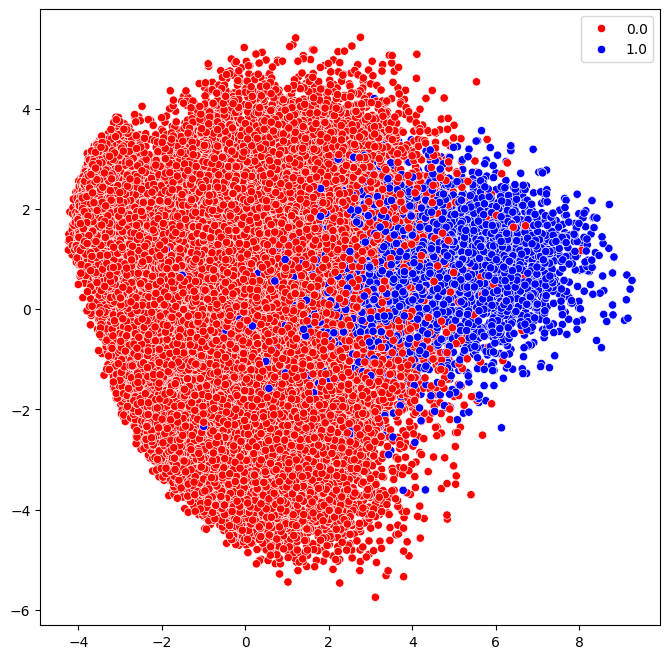

In [12]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=x_train_pca_2d[:,0],
    y=x_train_pca_2d[:,1],
    hue=y_train_0,
    palette=['r', 'b']
)

plt.show()

In [14]:
pipe_pca_3d= make_pipeline(MinMaxScaler(),PCA(n_components=3))
x_train_pca_3d = pipe_pca_3d.fit_transform(x_train)

In [16]:
import plotly.express as px
fig = px.scatter_3d(x=x_train_pca_3d[ :,0],
y=x_train_pca_3d[:,1],
z=x_train_pca_3d[:,2],
color=y_train_0,
color_discrete_map=cmap,
opacity=0.5)

fig.show()

In [17]:
# creating a new pipeline for classifer
pipe_clf_pca_2d= make_pipeline(pipe_pca_2d,KNeighborsClassifier(n_neighbors=3))

index_neg = np.argsort(y_train_0) [:5] #index of positive
index_pos = np.argsort(y_train_0) [-1 :- 6 :- 1] # index of negative samples

In [19]:
#ensure first 10 samples are mix of both classes
print("Pos_classes:", y_train_0[ index_pos ] )
print("Neg_classes:", y_train_0[ index_neg ] )


# Sanety Check
# create a small dataset
x = np.vstack((x_train[index_pos, : ], x_train[ index_neg, : ]) )
print(x.shape)
y = np.hstack((y_train_0[index_pos], y_train_0[ index_neg]))
print(y.shape)

Pos_classes: [1. 1. 1. 1. 1.]
Neg_classes: [0. 0. 0. 0. 0.]
(10, 784)
(10,)


In [20]:
pipe_clf_pca_2d.fit(x,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipeline', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-

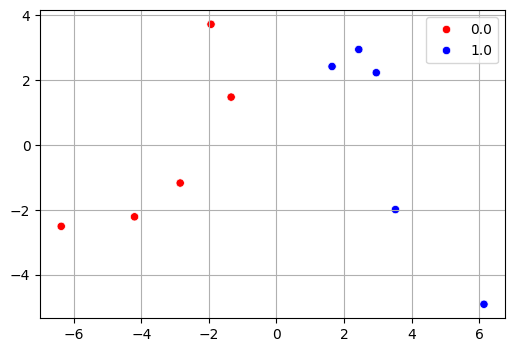

In [25]:
# for visualization
x_reduced = pipe_clf_pca_2d[0].transform(x)

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=x_reduced[:,0],
    y=x_reduced[:,1],
    marker='o',
    hue=y,
    palette=['r', 'b']
)

plt.grid(True)
plt.show()

Test labels: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


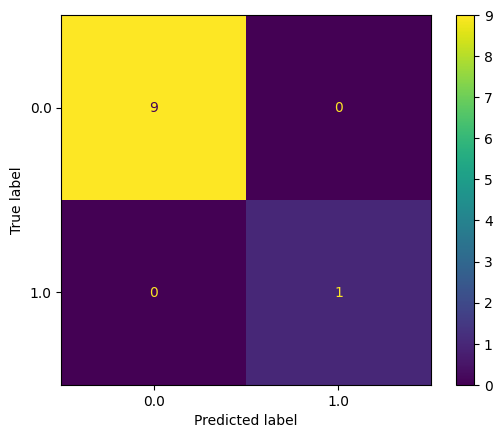

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

y_hat_0= pipe_clf_pca_2d.predict(x_test [ : 10, : ])
ConfusionMatrixDisplay.from_predictions(y_test_0[ : 10], y_hat_0)
print('Test labels:',y_test_0[ :10])
plt.show()